# IBM Data Science Capstone: Falcon 9 historical launch analysis

**Phyo Nyein Chan**. This executed notebook analyzes archived IBM Skills Network datasets from 2010-2020. It uses the supplied historical CSV outputs because the live SpaceX endpoint returned HTTP 525 during this revision. Dataset URLs and denominators are documented in `README.md`.

In [1]:
import analysis as a
import pandas as pd
from IPython.display import Image
print("Modeling cohort:",a.df.shape,"; date range:",a.df.Date.min(),"to",a.df.Date.max())
display(a.df.head())

{
  "cohort_n": 90,
  "sql_n": 101,
  "geo_n": 56,
  "dash_n": 56,
  "successes": 60,
  "rate": 0.6666666666666666,
  "date_min": "2010-06-04",
  "date_max": "2020-11-05",
  "best": "K nearest neighbors",
  "confusion": [
    [
      2,
      4
    ],
    [
      0,
      12
    ]
  ],
  "models": [
    {
      "model": "Logistic regression",
      "cv_accuracy": 0.86,
      "test_accuracy": 0.778,
      "test_f1": 0.857,
      "params": "{'model__C': 1}"
    },
    {
      "model": "Support vector machine",
      "cv_accuracy": 0.874,
      "test_accuracy": 0.778,
      "test_f1": 0.857,
      "params": "{'model__C': 1, 'model__kernel': 'rbf'}"
    },
    {
      "model": "Decision tree",
      "cv_accuracy": 0.846,
      "test_accuracy": 0.778,
      "test_f1": 0.857,
      "params": "{'max_depth': 2, 'min_samples_leaf': 2}"
    },
    {
      "model": "K nearest neighbors",
      "cv_accuracy": 0.874,
      "test_accuracy": 0.778,
      "test_f1": 0.857,
      "params": "{'model__n_

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class,Year
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0,2010
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0,2012
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0,2013
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0,2013
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0,2013


## Collection and wrangling

The course API workflow joins Falcon 9 launch, payload, core and launchpad details. The archived `dataset_part_2.csv` is its prepared output. The course scraping workflow normalizes a historical launch table; the separate IBM `Spacex.csv` supplies SQL records. The original live API and Wikipedia page were unavailable during this run, so this notebook does not claim a fresh collection.

In [2]:
print("Target distribution:")
display(a.df.Class.value_counts().sort_index().rename(index={0:"No landing",1:"Landing"}).to_frame("n"))
print("Missing values:")
display(a.df.isna().sum().loc[lambda s:s>0].to_frame("n"))
print("Duplicate FlightNumber:",int(a.df.FlightNumber.duplicated().sum()))

Target distribution:
Missing values:
Duplicate FlightNumber: 0


,n
Class,
No landing,30
Landing,60


,n
LandingPad,26


## Exploratory analysis with SQL

Executed SQLite queries group launch sites, payload masses, orbit categories and launch year. This SQL cohort has 101 rows and should not be combined silently with the 90-row model cohort.

In [3]:
for name,query in a.queries.items():
 print("\n",name,"\n",query)
 display(a.sql[name])


 sites 
 SELECT Launch_Site,COUNT(*) AS launches FROM SPACEXTBL GROUP BY Launch_Site ORDER BY launches DESC

 payload 
 SELECT ROUND(MIN(PAYLOAD_MASS__KG_),1) AS min_kg,ROUND(MAX(PAYLOAD_MASS__KG_),1) AS max_kg,ROUND(AVG(PAYLOAD_MASS__KG_),1) AS mean_kg FROM SPACEXTBL

 site_outcomes 
 SELECT Launch_Site,COUNT(*) AS launches,SUM(CASE WHEN Landing_Outcome LIKE 'Success%' THEN 1 ELSE 0 END) AS successful_landings FROM SPACEXTBL GROUP BY Launch_Site ORDER BY launches DESC

 orbit 
 SELECT Orbit,COUNT(*) AS launches FROM SPACEXTBL GROUP BY Orbit ORDER BY launches DESC LIMIT 8

 years 
 SELECT SUBSTR(Date,1,4) AS year,COUNT(*) AS launches,SUM(CASE WHEN Landing_Outcome LIKE 'Success%' THEN 1 ELSE 0 END) AS successful_landings FROM SPACEXTBL GROUP BY SUBSTR(Date,1,4) ORDER BY year


,Launch_Site,launches
0,CCAFS SLC-40,34
1,CCAFS LC-40,26
2,KSC LC-39A,25
3,VAFB SLC-4E,16


,min_kg,max_kg,mean_kg
0,0.0,15600.0,6138.3


,Launch_Site,launches,successful_landings
0,CCAFS SLC-40,34,25
1,CCAFS LC-40,26,6
2,KSC LC-39A,25,20
3,VAFB SLC-4E,16,10


,Orbit,launches
0,GTO,30
1,LEO (ISS),26
2,LEO,25
3,Polar LEO,8
4,SSO,6
5,MEO,3
6,HEO,2
7,Sub-orbital,1


,year,launches,successful_landings
0,2010,2,0
1,2012,2,0
2,2013,3,0
3,2014,6,0
4,2015,7,1
5,2016,8,5
6,2017,18,14
7,2018,20,10
8,2019,11,10
9,2020,24,21


## EDA visualization

The figures show historical site, orbit and year patterns, plus payload versus landing outcome. Small subgroup counts limit interpretation.

site_success.png
orbit_success.png
yearly.png
payload_year.png


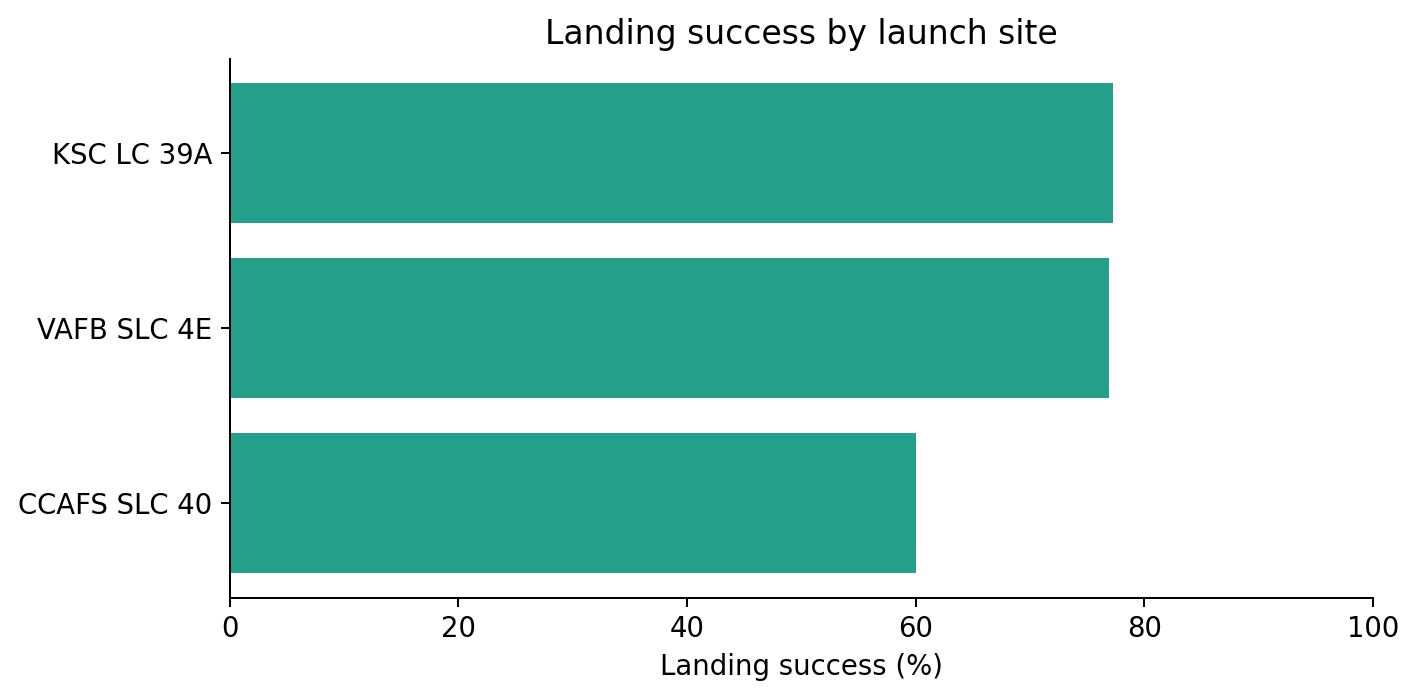

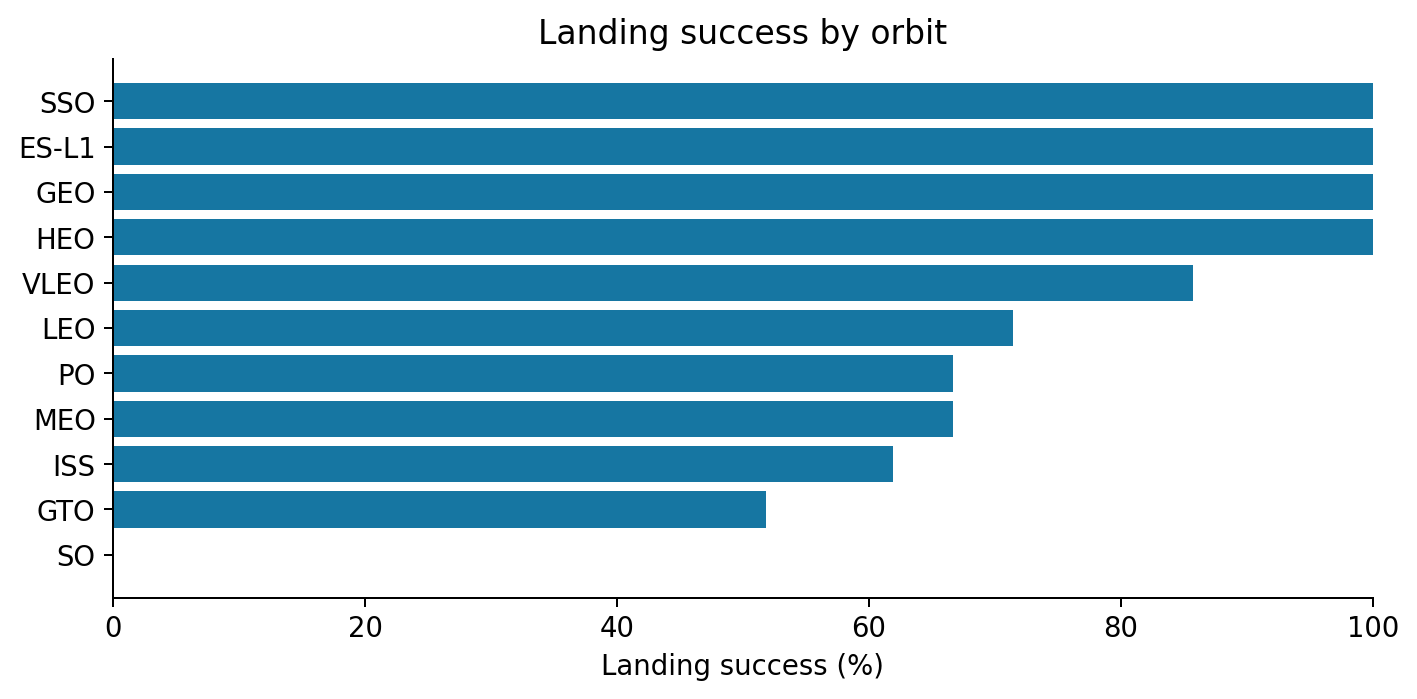

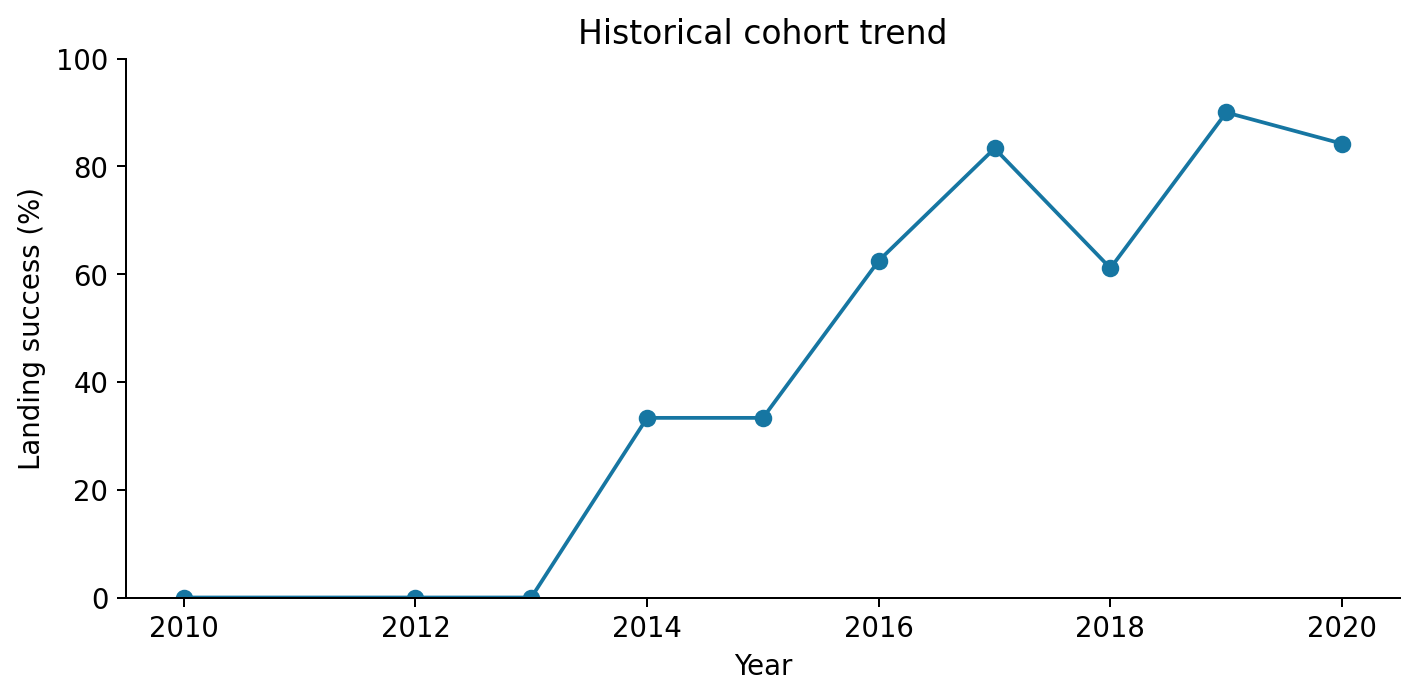

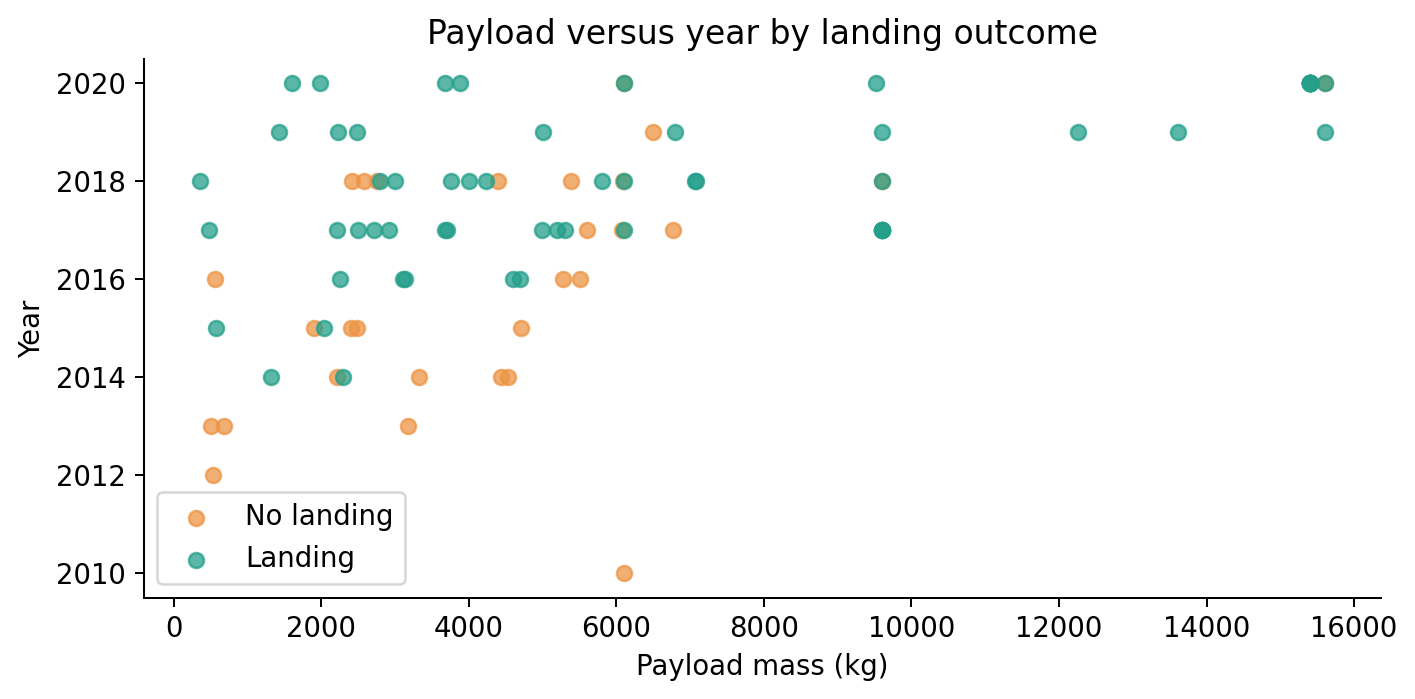

In [4]:
for name in ["site_success.png","orbit_success.png","yearly.png","payload_year.png"]:
 print(name);display(Image(filename=str(a.OUT/name)))

## Folium map and Plotly dashboard

The map uses 56 course geospatial rows, one marker per launch site and 5 km circles. The Plotly HTML uses 56 dashboard rows, a success pie and a payload/outcome scatter. Both HTML files accompany this notebook.

Folium map: /workspace/scratch/d196117dc56f/capstone_real/folium_map.html
Plotly dashboard: /workspace/scratch/d196117dc56f/capstone_real/plotly_dashboard.html


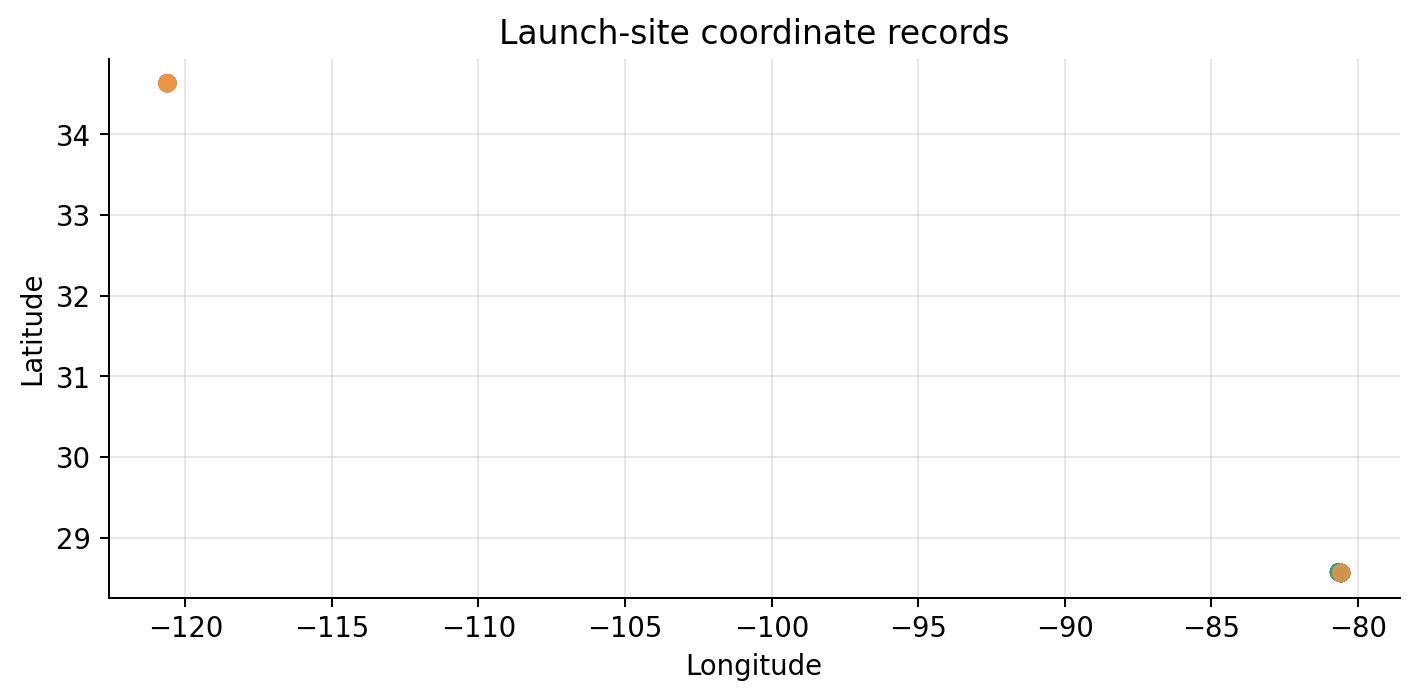

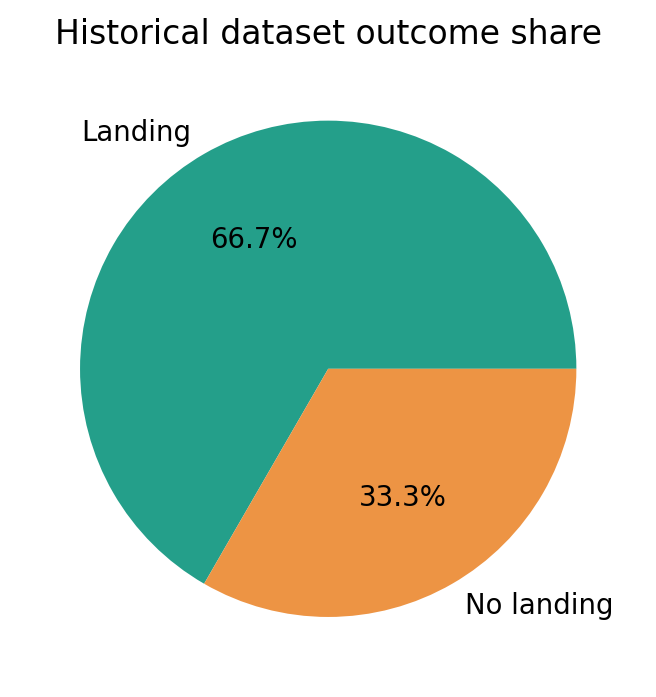

In [5]:
print("Folium map:",a.HERE/"folium_map.html")
print("Plotly dashboard:",a.HERE/"plotly_dashboard.html")
display(Image(filename=str(a.OUT/"geo.png")))
display(Image(filename=str(a.OUT/"pie.png")))

## Predictive analysis

A stratified 72/18 train/test split holds out final evaluation. GridSearchCV tunes four classifiers using five stratified folds. Scaling is confined to training folds in pipelines.

Selected by cross-validation: K nearest neighbors
Confusion matrix [0,1]:
 [[ 2  4]
 [ 0 12]]
Majority-class baseline: 0.667


,model,cv_accuracy,test_accuracy,test_f1,params
3,K nearest neighbors,0.874,0.778,0.857,{'model__n_neighbors': 5}
1,Support vector machine,0.874,0.778,0.857,"{'model__C': 1, 'model__kernel': 'rbf'}"
0,Logistic regression,0.860,0.778,0.857,{'model__C': 1}
2,Decision tree,0.846,0.778,0.857,"{'max_depth': 2, 'min_samples_leaf': 2}"


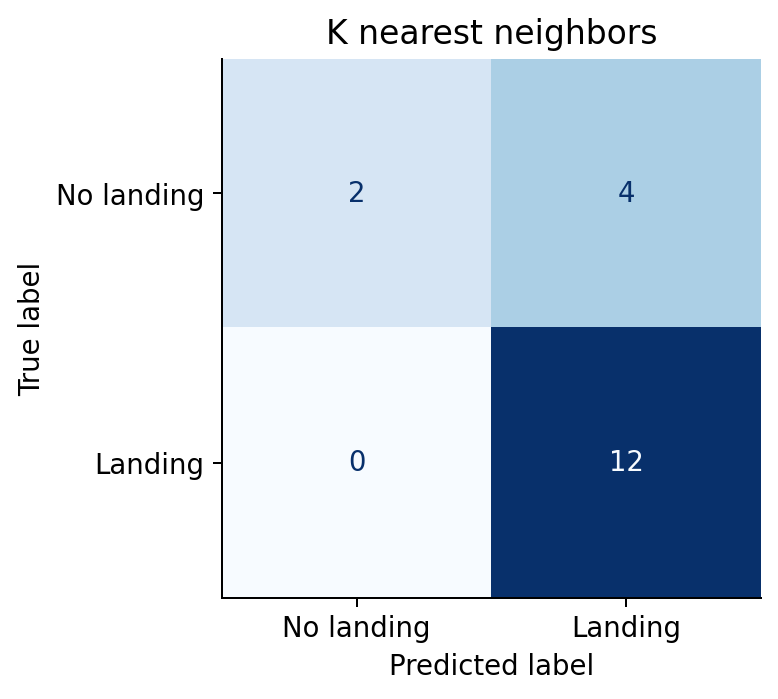

In [6]:
display(a.scores)
print("Selected by cross-validation:",a.best)
print("Confusion matrix [0,1]:\n",a.cm)
print("Majority-class baseline:",round(a.yte.mean(),3))
display(Image(filename=str(a.OUT/"confusion.png")))

## Interpretation

The selected KNN classifier achieves 77.8% held-out accuracy (14/18). It detects all 12 successful landings, while 4 of 6 unsuccessful landings are false positives. The 18-row test cohort is too small for a stable operational claim. Replicate this workflow on a later dataset before deployment.